In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import random
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import keras
from keras import layers, models, regularizers

from tensorflow.keras.applications import DenseNet169
from tensorflow.keras.applications.densenet import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from imblearn.over_sampling import SMOTE

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR = Path("../data")
IMAGES_DIR = DATA_DIR / "images"
MASKS_DIR = DATA_DIR / "masks"
CSV_PATH = DATA_DIR / "GroundTruth.csv"

IMG_SIZE = (256, 256)
BATCH_SIZE = 32
EPOCHS = 200
LEARNING_RATE = 0.0001

TEST_SIZE = 0.20
VAL_SIZE = 0.20

USE_DULL_RAZOR = False

USE_MASK_SEGMENTATION = False

USE_MASK_CROP = True
CROP_MARGIN = 20

BEST_MODEL_PATH = "best_densenet169_dull_crop_smote.keras"
FINAL_MODEL_PATH = "densenet169_dull_crop_smote_final.keras"
FEATURE_EXTRACTOR_PATH = "densenet169_dull_crop_feature_extractor.keras"

classes = ["MEL", "NV", "BCC", "AKIEC", "BKL", "DF", "VASC"]
class_code = {label: idx for idx, label in enumerate(classes)}
class_name = {idx: label for label, idx in class_code.items()}

print("IMG_SIZE:", IMG_SIZE)
print("BATCH_SIZE:", BATCH_SIZE)
print("EPOCHS:", EPOCHS)
print("LEARNING_RATE:", LEARNING_RATE)
print("USE_DULL_RAZOR:", USE_DULL_RAZOR)
print("USE_MASK_SEGMENTATION:", USE_MASK_SEGMENTATION)
print("USE_MASK_CROP:", USE_MASK_CROP)
print("CROP_MARGIN:", CROP_MARGIN)
print(class_code)

IMG_SIZE: (256, 256)
BATCH_SIZE: 32
EPOCHS: 200
LEARNING_RATE: 0.0001
USE_DULL_RAZOR: False
USE_MASK_SEGMENTATION: False
USE_MASK_CROP: True
CROP_MARGIN: 20
{'MEL': 0, 'NV': 1, 'BCC': 2, 'AKIEC': 3, 'BKL': 4, 'DF': 5, 'VASC': 6}


In [3]:
def find_image_path(image_id, images_dir):
    for ext in [".jpg", ".jpeg", ".png"]:
        path = images_dir / f"{image_id}{ext}"
        if path.exists():
            return str(path)
    return None


def find_mask_path(image_id, masks_dir):
    if not masks_dir.exists():
        return None

    candidates = [
        masks_dir / f"{image_id}_segmentation.png",
        masks_dir / f"{image_id}_segmentation.jpg",
        masks_dir / f"{image_id}_mask.png",
        masks_dir / f"{image_id}_mask.jpg",
        masks_dir / f"{image_id}.png",
        masks_dir / f"{image_id}.jpg",
    ]

    for path in candidates:
        if path.exists():
            return str(path)

    matches = list(masks_dir.glob(f"{image_id}*"))
    if len(matches) > 0:
        return str(matches[0])

    return None


metadata = pd.read_csv(CSV_PATH)

rows = []
for _, row in metadata.iterrows():
    image_id = str(row["image"])
    image_path = find_image_path(image_id, IMAGES_DIR)
    mask_path = find_mask_path(image_id, MASKS_DIR)

    if image_path is None:
        continue

    label_name = row[classes].idxmax()
    label = class_code[label_name]

    rows.append({
        "image": image_id,
        "image_path": image_path,
        "mask_path": mask_path,
        "class_name": label_name,
        "label": label
    })

df = pd.DataFrame(rows)

print("Total de imagens localizadas:", len(df))
display(df.head())

print("\nDistribuição original:")
print(df["class_name"].value_counts().reindex(classes))

print("\nMáscaras encontradas:", df["mask_path"].notna().sum())

Total de imagens localizadas: 10015


,image,image_path,mask_path,class_name,label
0,ISIC_0024306,../data/images/ISIC_0024306.jpg,../data/masks/ISIC_0024306_segmentation.png,NV,1
1,ISIC_0024307,../data/images/ISIC_0024307.jpg,../data/masks/ISIC_0024307_segmentation.png,NV,1
2,ISIC_0024308,../data/images/ISIC_0024308.jpg,../data/masks/ISIC_0024308_segmentation.png,NV,1
3,ISIC_0024309,../data/images/ISIC_0024309.jpg,../data/masks/ISIC_0024309_segmentation.png,NV,1
4,ISIC_0024310,../data/images/ISIC_0024310.jpg,../data/masks/ISIC_0024310_segmentation.png,MEL,0



Distribuição original:
class_name
MEL      1113
NV       6705
BCC       514
AKIEC     327
BKL      1099
DF        115
VASC      142
Name: count, dtype: int64

Máscaras encontradas: 10015


In [4]:
train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=df["label"]
)

print("Treino original:", len(train_df))
print("Teste final:", len(test_df))

print("\nDistribuição treino original:")
print(train_df["class_name"].value_counts().reindex(classes))

print("\nDistribuição teste final:")
print(test_df["class_name"].value_counts().reindex(classes))

Treino original: 8012
Teste final: 2003

Distribuição treino original:
class_name
MEL       890
NV       5364
BCC       411
AKIEC     262
BKL       879
DF         92
VASC      114
Name: count, dtype: int64

Distribuição teste final:
class_name
MEL       223
NV       1341
BCC       103
AKIEC      65
BKL       220
DF         23
VASC       28
Name: count, dtype: int64


In [5]:
def read_rgb_image(path):
    if isinstance(path, bytes):
        path = path.decode("utf-8")

    image_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)

    if image_bgr is None:
        raise ValueError(f"Não foi possível carregar a imagem: {path}")

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    return image_rgb


def dull_razor_remove_hair(image_rgb, kernel_size=(9, 9), threshold_value=10, inpaint_radius=6):
    image_rgb = image_rgb.astype(np.uint8)

    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, kernel_size)
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)

    blackhat_blur = cv2.GaussianBlur(blackhat, (3, 3), 0)

    _, mask = cv2.threshold(
        blackhat_blur,
        threshold_value,
        255,
        cv2.THRESH_BINARY
    )

    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)

    clean_bgr = cv2.inpaint(
        image_bgr,
        mask,
        inpaint_radius,
        cv2.INPAINT_TELEA
    )

    clean_rgb = cv2.cvtColor(clean_bgr, cv2.COLOR_BGR2RGB)

    return clean_rgb


def read_binary_mask(mask_path, target_shape):
    if mask_path is None or pd.isna(mask_path):
        return None

    if isinstance(mask_path, bytes):
        mask_path = mask_path.decode("utf-8")

    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    if mask is None:
        return None

    height, width = target_shape[:2]
    mask = cv2.resize(mask, (width, height))

    binary_mask = (mask > 127).astype(np.uint8)

    return binary_mask


def apply_mask_segmentation(image_rgb, mask_path):
    binary_mask = read_binary_mask(mask_path, target_shape=image_rgb.shape)

    if binary_mask is None:
        return image_rgb

    segmented = image_rgb * np.expand_dims(binary_mask, axis=-1)

    # Proteção contra máscara ruim.
    if np.mean(segmented) < 5:
        return image_rgb

    return segmented


def crop_lesion_with_margin(image_rgb, mask_path, margin=20):
    binary_mask = read_binary_mask(mask_path, target_shape=image_rgb.shape)

    if binary_mask is None:
        return image_rgb

    ys, xs = np.where(binary_mask > 0)

    if len(xs) == 0 or len(ys) == 0:
        return image_rgb

    height, width = image_rgb.shape[:2]

    x_min = max(xs.min() - margin, 0)
    x_max = min(xs.max() + margin, width - 1)
    y_min = max(ys.min() - margin, 0)
    y_max = min(ys.max() + margin, height - 1)

    cropped = image_rgb[y_min:y_max + 1, x_min:x_max + 1]

    if cropped.size == 0:
        return image_rgb

    return cropped


def preprocess_image_path(path, mask_path=None):
    image_rgb = read_rgb_image(path)

    if USE_DULL_RAZOR:
        image_rgb = dull_razor_remove_hair(image_rgb)

    if USE_MASK_CROP:
        image_rgb = crop_lesion_with_margin(
            image_rgb,
            mask_path,
            margin=CROP_MARGIN
        )
    elif USE_MASK_SEGMENTATION:
        image_rgb = apply_mask_segmentation(image_rgb, mask_path)

    image_rgb = cv2.resize(image_rgb, IMG_SIZE)

    return image_rgb.astype("float32")

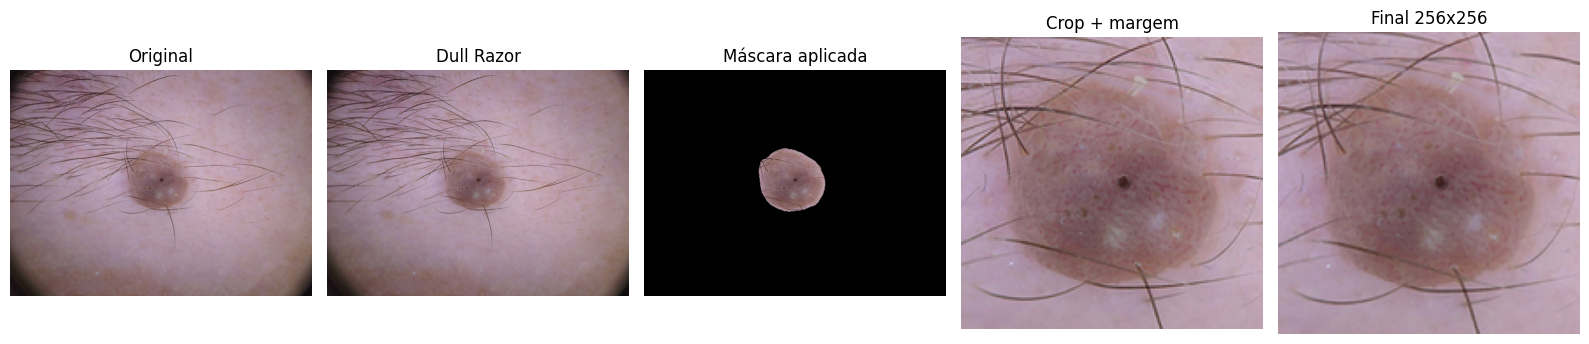

In [6]:
sample_row = train_df.sample(1, random_state=SEED).iloc[0]

original = read_rgb_image(sample_row["image_path"])
dull = dull_razor_remove_hair(original) if USE_DULL_RAZOR else original
segmented = apply_mask_segmentation(dull, sample_row["mask_path"])
cropped = crop_lesion_with_margin(dull, sample_row["mask_path"], margin=CROP_MARGIN)
final_img = preprocess_image_path(sample_row["image_path"], sample_row["mask_path"])
final_img = np.clip(final_img, 0, 255).astype("uint8")

plt.figure(figsize=(16, 4))

plt.subplot(1, 5, 1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 5, 2)
plt.imshow(dull)
plt.title("Dull Razor")
plt.axis("off")

plt.subplot(1, 5, 3)
plt.imshow(np.clip(segmented, 0, 255).astype("uint8"))
plt.title("Máscara aplicada")
plt.axis("off")

plt.subplot(1, 5, 4)
plt.imshow(np.clip(cropped, 0, 255).astype("uint8"))
plt.title("Crop + margem")
plt.axis("off")

plt.subplot(1, 5, 5)
plt.imshow(final_img)
plt.title("Final 256x256")
plt.axis("off")

plt.tight_layout()
plt.savefig("pipeline_densenet169_dull_crop_smote.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
def load_image_for_features_py(image_path, mask_path, label):
    if isinstance(image_path, bytes):
        image_path = image_path.decode("utf-8")

    if isinstance(mask_path, bytes):
        mask_path = mask_path.decode("utf-8")

    if mask_path == "None" or mask_path == "":
        mask_path = None

    image = preprocess_image_path(image_path, mask_path)

    return image.astype("float32"), np.int32(label)


def tf_load_image_for_features(image_path, mask_path, label):
    image, label = tf.numpy_function(
        load_image_for_features_py,
        [image_path, mask_path, label],
        [tf.float32, tf.int32]
    )

    image.set_shape((IMG_SIZE[0], IMG_SIZE[1], 3))
    label.set_shape(())

    return image, label


def build_image_dataset(dataframe, batch_size=BATCH_SIZE, shuffle=False):
    mask_values = dataframe["mask_path"].fillna("None").astype(str).values

    ds = tf.data.Dataset.from_tensor_slices((
        dataframe["image_path"].astype(str).values,
        mask_values,
        dataframe["label"].values.astype("int32")
    ))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED)

    ds = ds.map(tf_load_image_for_features, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds


train_image_ds = build_image_dataset(train_df, shuffle=False)
test_image_ds = build_image_dataset(test_df, shuffle=False)

print(train_image_ds)
print(test_image_ds)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [8]:
def build_feature_extractor(input_shape=(256, 256, 3)):
    inputs = layers.Input(shape=input_shape)

    x = preprocess_input(inputs)

    base_model = DenseNet169(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )

    base_model.trainable = False

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    feature_extractor = models.Model(
        inputs=inputs,
        outputs=x,
        name="densenet169_dull_crop_feature_extractor"
    )

    return feature_extractor


feature_extractor = build_feature_extractor(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

feature_extractor.summary()

Model: "densenet169_dull_crop_feature_extractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet169 (Functional)        │ (None, 8, 8, 1664)     │    12,642,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1664)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,642,880 (48.23 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 12,642,880 (48.23 MB)

In [9]:
def extract_features(dataset, feature_extractor):
    features_list = []
    labels_list = []

    for images, labels in dataset:
        features = feature_extractor.predict(images, verbose=0)
        features_list.append(features)
        labels_list.append(labels.numpy())

    X = np.concatenate(features_list, axis=0)
    y = np.concatenate(labels_list, axis=0)

    return X.astype("float32"), y.astype("int32")


X_train_features, y_train = extract_features(train_image_ds, feature_extractor)
X_test_features, y_test = extract_features(test_image_ds, feature_extractor)

print("X_train_features:", X_train_features.shape)
print("y_train:", y_train.shape)
print("X_test_features:", X_test_features.shape)
print("y_test:", y_test.shape)

print("\nDistribuição treino antes do SMOTE:")
print(Counter(y_train))

X_train_features: (8012, 1664)
y_train: (8012,)
X_test_features: (2003, 1664)
y_test: (2003,)

Distribuição treino antes do SMOTE:
Counter({np.int32(1): 5364, np.int32(0): 890, np.int32(4): 879, np.int32(2): 411, np.int32(3): 262, np.int32(6): 114, np.int32(5): 92})


In [10]:
min_class_count = min(Counter(y_train).values())
k_neighbors = min(5, min_class_count - 1)

print("Menor classe no treino:", min_class_count)
print("k_neighbors usado no SMOTE:", k_neighbors)

smote = SMOTE(
    random_state=SEED,
    k_neighbors=k_neighbors
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_features,
    y_train
)

print("X_train_smote:", X_train_smote.shape)
print("y_train_smote:", y_train_smote.shape)

print("\nDistribuição treino após SMOTE:")
print(Counter(y_train_smote))

Menor classe no treino: 92
k_neighbors usado no SMOTE: 5
X_train_smote: (37548, 1664)
y_train_smote: (37548,)

Distribuição treino após SMOTE:
Counter({np.int32(1): 5364, np.int32(0): 5364, np.int32(4): 5364, np.int32(2): 5364, np.int32(5): 5364, np.int32(3): 5364, np.int32(6): 5364})


In [11]:
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train_smote,
    y_train_smote,
    test_size=VAL_SIZE,
    random_state=SEED,
    stratify=y_train_smote
)

print("Treino para fit:", X_fit.shape)
print("Validação:", X_val.shape)
print("Teste final:", X_test_features.shape)

print("\nDistribuição fit:")
print(Counter(y_fit))

print("\nDistribuição validação:")
print(Counter(y_val))

Treino para fit: (30038, 1664)
Validação: (7510, 1664)
Teste final: (2003, 1664)

Distribuição fit:
Counter({np.int32(0): 4292, np.int32(4): 4291, np.int32(5): 4291, np.int32(6): 4291, np.int32(2): 4291, np.int32(3): 4291, np.int32(1): 4291})

Distribuição validação:
Counter({np.int32(2): 1073, np.int32(3): 1073, np.int32(6): 1073, np.int32(4): 1073, np.int32(1): 1073, np.int32(5): 1073, np.int32(0): 1072})


In [12]:
def build_classifier_head(input_dim, num_classes=len(classes)):
    inputs = layers.Input(shape=(input_dim,))

    x = layers.Dense(
        256,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    )(inputs)

    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    )(x)

    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="densenet169_dull_crop_smote_classifier"
    )

    return model


classifier = build_classifier_head(
    input_dim=X_train_smote.shape[1],
    num_classes=len(classes)
)

classifier.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

classifier.summary()

Model: "densenet169_dull_crop_smote_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 1664)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       426,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 461,063 (1.76 MB)

 Trainable params: 460,551 (1.76 MB)

 Non-trainable params: 512 (2.00 KB)

In [13]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=4,
        min_lr=1e-7,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        BEST_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

history = classifier.fit(
    X_fit,
    y_fit,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks
)

Epoch 1/200
918/939 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4453 - loss: 2.1191
Epoch 1: val_loss improved from None to 0.96654, saving model to best_densenet169_dull_crop_smote.keras

Epoch 1: finished saving model to best_densenet169_dull_crop_smote.keras
939/939 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5636 - loss: 1.6829 - val_accuracy: 0.7968 - val_loss: 0.9665 - learning_rate: 1.0000e-04
Epoch 2/200
921/939 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7068 - loss: 1.1885
Epoch 2: val_loss improved from 0.96654 to 0.77089, saving model to best_densenet169_dull_crop_smote.keras

Epoch 2: finished saving model to best_densenet169_dull_crop_smote.keras
939/939 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7287 - loss: 1.1135 - val_accuracy: 0.8621 - val_loss: 0.7709 - learning_rate: 1.0000e-04
Epoch 3/200
915/939 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7768 - loss: 0.9649
Epoch 3: val_loss improved from 0.77089 to 0.66512, saving model to best_densenet169_dull_

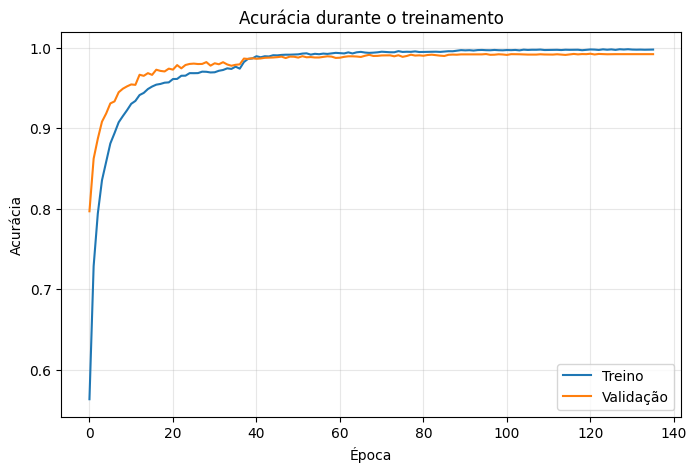

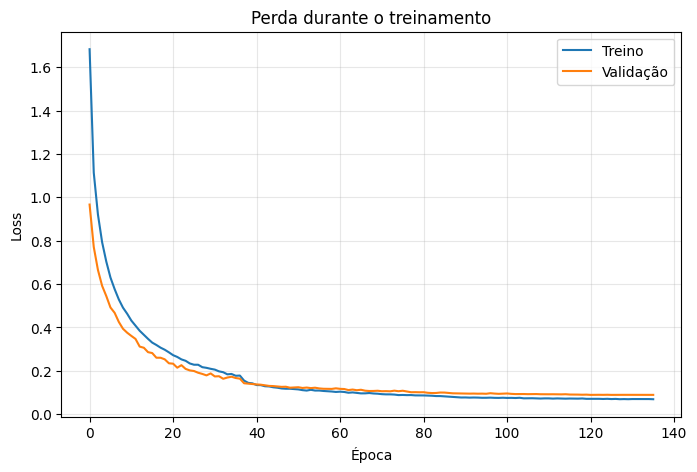

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Treino")
plt.plot(history.history["val_accuracy"], label="Validação")
plt.title("Acurácia durante o treinamento")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("acuracia_densenet169_dull_crop_smote.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Treino")
plt.plot(history.history["val_loss"], label="Validação")
plt.title("Perda durante o treinamento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("loss_densenet169_dull_crop_smote.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
best_classifier = keras.models.load_model(BEST_MODEL_PATH)

pred_probs = best_classifier.predict(X_test_features, verbose=0)
y_pred = np.argmax(pred_probs, axis=1)

print("Relatório de Classificação:")
print(classification_report(
    y_test,
    y_pred,
    target_names=classes,
    digits=4,
    zero_division=0
))

acc = accuracy_score(y_test, y_pred)

macro_precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
macro_recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

weighted_precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
weighted_recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
weighted_f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print("\nMÉTRICAS GERAIS DO MODELO")
print(f"Accuracy: {acc:.4f}")

print("\nMacro Average:")
print(f"  Precision: {macro_precision:.4f}")
print(f"  Recall: {macro_recall:.4f}")
print(f"  F1-Score: {macro_f1:.4f}")

print("\nWeighted Average:")
print(f"  Precision: {weighted_precision:.4f}")
print(f"  Recall: {weighted_recall:.4f}")
print(f"  F1-Score: {weighted_f1:.4f}")

Relatório de Classificação:
              precision    recall  f1-score   support

         MEL     0.6927    0.5964    0.6410       223
          NV     0.9193    0.9515    0.9351      1341
         BCC     0.7545    0.8058    0.7793       103
       AKIEC     0.6066    0.5692    0.5873        65
         BKL     0.6954    0.6227    0.6571       220
          DF     0.7500    0.9130    0.8235        23
        VASC     0.8519    0.8214    0.8364        28

    accuracy                         0.8537      2003
   macro avg     0.7529    0.7543    0.7514      2003
weighted avg     0.8480    0.8537    0.8499      2003


MÉTRICAS GERAIS DO MODELO
Accuracy: 0.8537

Macro Average:
  Precision: 0.7529
  Recall: 0.7543
  F1-Score: 0.7514

Weighted Average:
  Precision: 0.8480
  Recall: 0.8537
  F1-Score: 0.8499


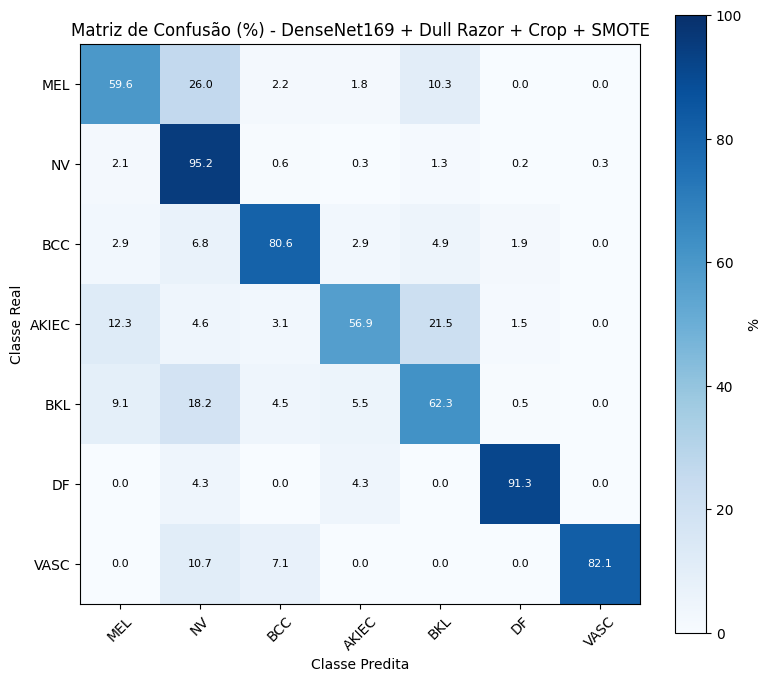

In [16]:
cm = confusion_matrix(y_test, y_pred, labels=list(range(len(classes))))
cm_percent = cm.astype("float") / cm.sum(axis=1, keepdims=True) * 100
cm_percent = np.nan_to_num(cm_percent)

plt.figure(figsize=(8, 7))
im = plt.imshow(cm_percent, interpolation="nearest", cmap="Blues", vmin=0, vmax=100)
plt.title("Matriz de Confusão (%) - DenseNet169 + Dull Razor + Crop + SMOTE")
plt.colorbar(im, label="%")

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

for i in range(cm_percent.shape[0]):
    for j in range(cm_percent.shape[1]):
        color = "white" if cm_percent[i, j] > 50 else "black"
        plt.text(
            j,
            i,
            f"{cm_percent[i, j]:.1f}",
            ha="center",
            va="center",
            color=color,
            fontsize=8
        )

plt.ylabel("Classe Real")
plt.xlabel("Classe Predita")
plt.tight_layout()
plt.savefig("matriz_confusao_percent_densenet169_dull_crop_smote.png", dpi=300, bbox_inches="tight")
plt.show()

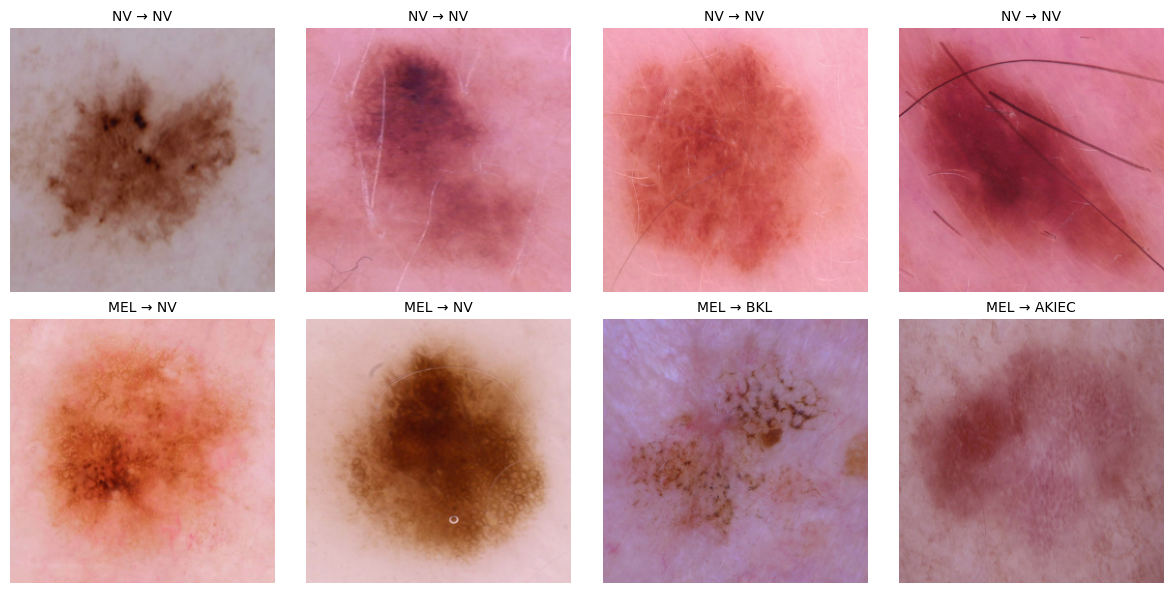

In [17]:
test_eval_df = test_df.copy().reset_index(drop=True)
test_eval_df["y_true"] = y_test
test_eval_df["y_pred"] = y_pred
test_eval_df["correct"] = test_eval_df["y_true"] == test_eval_df["y_pred"]

correct_samples = test_eval_df[test_eval_df["correct"]].head(4)
incorrect_samples = test_eval_df[~test_eval_df["correct"]].head(4)

samples_to_plot = pd.concat([correct_samples, incorrect_samples], axis=0).reset_index(drop=True)

plt.figure(figsize=(12, 6))

for i, row in samples_to_plot.iterrows():
    image = preprocess_image_path(row["image_path"], row["mask_path"])
    image = np.clip(image, 0, 255).astype("uint8")

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)

    true_label = class_name[int(row["y_true"])]
    pred_label = class_name[int(row["y_pred"])]

    plt.title(f"{true_label} → {pred_label}", fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.savefig("exemplos_classificacao_densenet169_dull_crop_smote.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
feature_extractor.save(FEATURE_EXTRACTOR_PATH)
best_classifier.save(FINAL_MODEL_PATH)

print("Extratora DenseNet169 salva em:", FEATURE_EXTRACTOR_PATH)
print("Classificador final salvo em:", FINAL_MODEL_PATH)
print("Melhor checkpoint salvo em:", BEST_MODEL_PATH)

Extratora DenseNet169 salva em: densenet169_dull_crop_feature_extractor.keras
Classificador final salvo em: densenet169_dull_crop_smote_final.keras
Melhor checkpoint salvo em: best_densenet169_dull_crop_smote.keras
